# HRP versus inverse-variance and CLA, out of sample (SYNTHETIC Monte Carlo)

> **Every number in this notebook comes from SYNTHETIC data.** The main study is López de Prado's own
> Monte Carlo experiment (AFML §16.6, Snippets 16.4 and 16.5): simulated returns with a known
> correlation structure and injected shocks. The short illustration at the end uses the committed
> SYNTHETIC sample `SYN_A`..`SYN_E` read through `openquant.data.fetch`. Nothing here is a statement
> about a real market. To run the illustration on your own data, set `SOURCE` in the setup cell
> (see *Data*).

Runbook for [issue #51](https://github.com/Open-Quant/openquant/issues/51). It follows the notebook
contract of [#46](https://github.com/Open-Quant/openquant/issues/46): setup, hypothesis, data, method,
results, analysis, promotion decision, reproducibility footer.

## Setup

In [1]:
from __future__ import annotations

import hashlib
import math
import os
from importlib.metadata import version

import nbfigures
import numpy as np
import openquant
import polars as pl
from openquant import cla, hrp

# Monte Carlo size. CI runs N_RUNS_CI; set OPENQUANT_RUNBOOK_RUNS=10000 to match the book's count.
N_RUNS_CI = 2000
N_RUNS = int(os.environ.get("OPENQUANT_RUNBOOK_RUNS", N_RUNS_CI))
SEED = 51  # the issue number; run k draws from np.random.default_rng([SEED, k])

# AFML Snippet 16.5 parameters, unchanged.
N_OBS = 520  # observations per path: 260 in-sample warm-up + 260 out-of-sample
S_LENGTH = 260  # rolling in-sample window (about one year of daily bars)
REBAL = 22  # rebalance every 22 observations (about one month)
SIZE0 = 5  # uncorrelated "original" series
SIZE1 = 5  # series built as noisy copies of randomly chosen originals
MU0 = 0.0
SIGMA0 = 1e-2
SIGMA1F = 0.25  # noise of the copies, as a fraction of SIGMA0

# Stated cost model: proportional, 10 bps of notional per unit of one-way turnover, charged on the
# first out-of-sample observation after each rebalance (the first allocation is charged too).
COST_BPS = 10.0

# Illustration on the fetch() data layer. SOURCE=None is the committed SYNTHETIC sample; pass your own
# DataSource (e.g. openquant.data.LocalFileSource("my_bars.parquet")) with your symbols and dates.
SOURCE = None
SYMBOLS = ["SYN_A", "SYN_B", "SYN_C", "SYN_D", "SYN_E"]
START, END = "2022-01-03", "2023-12-29"

print(f"Monte Carlo runs: {N_RUNS} (CI default {N_RUNS_CI}; the book uses 10000)")
print(f"path: {N_OBS} obs, window {S_LENGTH}, rebalance every {REBAL}, {SIZE0 + SIZE1} assets")

Monte Carlo runs: 2000 (CI default 2000; the book uses 10000)
path: 520 obs, window 260, rebalance every 22, 10 assets


## Hypothesis

AFML §16.6 argues that HRP, which never inverts the covariance matrix, is more robust to estimation
error than the minimum-variance portfolio that does, and more diversified than inverse-variance
weighting, which ignores correlation. Stated as falsifiable claims about the Snippet 16.4 process,
decided on the paired per-run out-of-sample (OOS) variance, one-sided at the 5% level:

- **H1 (vs CLA).** HRP's OOS variance is lower than that of CLA's minimum-variance portfolio:
  the mean of $\log(\sigma^2_{\text{CLA}}/\sigma^2_{\text{HRP}})$ over runs is positive with $t > 1.645$.
- **H2 (vs IVP).** HRP's OOS variance is comparable to or lower than inverse-variance weighting:
  the mean of $\log(\sigma^2_{\text{IVP}}/\sigma^2_{\text{HRP}})$ is not significantly negative ($t > -1.645$).

Both are rejected if their condition fails. The rule was fixed before the full run; the number of
runs is the only parameter that differs between CI and a local run.

## Data

**Monte Carlo (the study).** Snippet 16.4, re-implemented with NumPy:

1. Draw $N_{obs}\times 5$ independent normal returns with mean $\mu_0=0$ and s.d. $\sigma_0=1\%$.
2. Pick 5 of those columns at random, with replacement, and append a noisy copy of each (noise s.d.
   $0.25\,\sigma_0$). The copies make 10 assets with a cluster structure the allocator must discover.
3. **Common shock:** at two random out-of-sample dates, set one original column and its first copy to
   $-50\%$ and then $+200\%$.
4. **Specific shock:** at two other random out-of-sample dates, set one original column alone to
   $-50\%$ and $+200\%$.

The shocks fall only in the out-of-sample half, so no in-sample estimate can anticipate them; they are
there to reward allocations that did not concentrate risk in one cluster or one asset.

**Your own data.** The illustration section reads daily bars with `openquant.data.fetch(SYMBOLS, START,
END, source=SOURCE)`. With `SOURCE = None` that is the committed SYNTHETIC sample. For your own data:

```python
from openquant.data import LocalFileSource
SOURCE = LocalFileSource("my_daily_bars.parquet")  # columns: ts, symbol, close (or adj_close), ...
SYMBOLS = ["AAA", "BBB", "CCC", "DDD", "EEE", "FFF"]
START, END = "2015-01-02", "2024-12-31"
```

or wrap a vendor client in `openquant.data.CallableSource` (see `DATA_SOURCES.md`). Five symbols over
two years is far too small for an allocation study; a real universe needs tens of assets and many years,
and a single path gives one draw, not a distribution.

In [2]:
def generate(rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    """AFML Snippet 16.4: correlated returns with common and specific shocks (rows are observations)."""
    x = rng.normal(MU0, SIGMA0, size=(N_OBS, SIZE0))
    cols = rng.integers(0, SIZE0, size=SIZE1)
    y = x[:, cols] + rng.normal(0.0, SIGMA0 * SIGMA1F, size=(N_OBS, SIZE1))
    x = np.append(x, y, axis=1)
    point = rng.integers(S_LENGTH, N_OBS - 1, size=2)  # common shock, out of sample only
    x[np.ix_(point, [cols[0], SIZE0])] = np.array([[-0.5, -0.5], [2.0, 2.0]])
    point = rng.integers(S_LENGTH, N_OBS - 1, size=2)  # specific shock, out of sample only
    x[point, cols[-1]] = np.array([-0.5, 2.0])
    return x, cols


example, example_cols = generate(np.random.default_rng([SEED, 0]))
corr = np.corrcoef(example[:S_LENGTH], rowvar=False)
print("run 0: copies 5..9 are noisy copies of originals", example_cols.tolist())
print("run 0: in-sample correlation of each copy with its original:")
print("  " + "  ".join(f"{5 + j}~{c}: {corr[5 + j, c]:.3f}" for j, c in enumerate(example_cols)))
print(
    "run 0: out-of-sample rows with a shock:",
    sorted(set(np.nonzero(np.abs(example) >= 0.5)[0].tolist())),
)

run 0: copies 5..9 are noisy copies of originals [4, 2, 3, 4, 4]
run 0: in-sample correlation of each copy with its original:
  5~4: 0.973  6~2: 0.972  7~3: 0.970  8~4: 0.971  9~4: 0.977
run 0: out-of-sample rows with a shock: [346, 426, 449, 495]


## Method

Snippet 16.5, per run: at each rebalance date $t\in\{260, 282, \dots, 502\}$ estimate the sample
covariance on rows $[t-260, t)$ only, compute each method's weights from it, and hold them for rows
$[t, t+22)$ (the last block is 18 rows). The 12 blocks form a 260-row OOS return series per method,
and the run's statistic is that series' variance. All methods see the same covariance matrix.

| Method | Weights |
| --- | --- |
| **HRP** | `openquant.hrp.allocate_hrp(names, covariance_matrix=cov)` |
| **CLA** | `openquant.cla.allocate_cla(..., solution="min_volatility")`: the minimum-variance turning point, long-only, weights in $[0,1]$. As in the book, the expected returns are a dummy `0, 1, ..., 9` (they do not affect the minimum-variance point). |
| **IVP** | $w_i \propto 1/\Sigma_{ii}$, computed here in NumPy |
| EW (reference) | $w_i = 1/10$, which uses no estimate at all |

HCAA is not run: with `"minimum_variance"` it currently returns HRP's weights to the last bit
([#108](https://github.com/Open-Quant/openquant/issues/108)), so it would duplicate the HRP column.

Besides variance: **concentration** (effective number of assets $1/\sum w_i^2$ and the largest weight,
averaged over rebalances), **turnover** ($\sum_i |w_{i,t}-w_{i,t-1}|$ per rebalance, starting from
cash), and the OOS variance **net of the cost model**. Sharpe ratios are not reported for the Monte
Carlo: the simulated returns have mean zero, so any Sharpe is noise.

In [3]:
NAMES = [f"asset_{i}" for i in range(SIZE0 + SIZE1)]
DUMMY_MU = [float(i) for i in range(SIZE0 + SIZE1)]  # Snippet 16.5's placeholder for CLA


def w_hrp(cov: np.ndarray) -> np.ndarray:
    return np.asarray(hrp.allocate_hrp(NAMES[: len(cov)], covariance_matrix=cov.tolist())[0])


def w_cla(cov: np.ndarray) -> np.ndarray:
    out = cla.allocate_cla(
        expected_returns=DUMMY_MU[: len(cov)],
        covariance_matrix=cov.tolist(),
        solution="min_volatility",
    )
    return np.asarray(out["weights"][0])


def w_ivp(cov: np.ndarray) -> np.ndarray:
    iv = 1.0 / np.diag(cov)
    return iv / iv.sum()


def w_ew(cov: np.ndarray) -> np.ndarray:
    return np.full(len(cov), 1.0 / len(cov))


METHODS = {"HRP": w_hrp, "CLA": w_cla, "IVP": w_ivp, "EW": w_ew}


def rebalance_weights(x: np.ndarray, t: int) -> dict[str, np.ndarray]:
    """Weights at rebalance t, from rows [t - S_LENGTH, t) only."""
    cov = np.cov(x[t - S_LENGTH : t], rowvar=False)
    return {k: f(cov) for k, f in METHODS.items()}


def backtest(x: np.ndarray) -> dict[str, dict[str, float]]:
    stats: dict[str, dict[str, float]] = {}
    gross = {k: [] for k in METHODS}
    net = {k: [] for k in METHODS}
    prev = {k: np.zeros(x.shape[1]) for k in METHODS}
    conc = {k: [] for k in METHODS}
    maxw = {k: [] for k in METHODS}
    turn = {k: [] for k in METHODS}
    for t in range(S_LENGTH, N_OBS, REBAL):
        oos = x[t : t + REBAL]
        for k, w in rebalance_weights(x, t).items():
            r = oos @ w
            to = float(np.abs(w - prev[k]).sum())
            r_net = r.copy()
            r_net[0] -= COST_BPS * 1e-4 * to
            gross[k].append(r)
            net[k].append(r_net)
            turn[k].append(to)
            conc[k].append(1.0 / float(np.sum(w**2)))
            maxw[k].append(float(w.max()))
            prev[k] = w
    for k in METHODS:
        g = np.concatenate(gross[k])
        stats[k] = {
            "var": float(g.var(ddof=1)),
            "var_net": float(np.concatenate(net[k]).var(ddof=1)),
            "eff_n": float(np.mean(conc[k])),
            "max_w": float(np.mean(maxw[k])),
            "turnover": float(np.mean(turn[k][1:])),  # per rebalance, excluding the initial buy
        }
    return stats


# No-lookahead test: weights at every rebalance must not change when every row from t on is replaced.
x0, _ = generate(np.random.default_rng([SEED, 0]))
junk = np.random.default_rng([SEED, 10**9])
for t in range(S_LENGTH, N_OBS, REBAL):
    tampered = x0.copy()
    tampered[t:] = junk.normal(0.0, 0.5, size=tampered[t:].shape)
    a, b = rebalance_weights(x0, t), rebalance_weights(tampered, t)
    assert all(np.array_equal(a[k], b[k]) for k in METHODS), f"lookahead at t={t}"
    # and the check has teeth: rows before t do move the weights
    tampered[t - 1] += 0.1
    assert not np.array_equal(rebalance_weights(tampered, t)["HRP"], a["HRP"])
print(f"no-lookahead test passed at all {len(range(S_LENGTH, N_OBS, REBAL))} rebalance dates")

no-lookahead test passed at all 12 rebalance dates


In [4]:
records = []
data_digest = hashlib.sha256()
for run in range(N_RUNS):
    x, _ = generate(np.random.default_rng([SEED, run]))
    data_digest.update(np.round(x, 10).tobytes())
    for method, s in backtest(x).items():
        records.append({"run": run, "method": method, **s})

runs = pl.DataFrame(records)
MC_DATA_HASH = "sha256:" + data_digest.hexdigest()
print(f"{N_RUNS} runs x {len(METHODS)} methods = {runs.height} rows")
print("simulated data hash (values rounded to 1e-10):", MC_DATA_HASH)

2000 runs x 4 methods = 8000 rows
simulated data hash (values rounded to 1e-10): sha256:4d7244f3bfde30f5e2cf082468941a4a64c6f0200dfd8bcc3ffe07f5f29879cc


## Results

In [5]:
ORDER = ["HRP", "IVP", "CLA", "EW"]
wide = runs.pivot(on="method", index="run", values="var").sort("run")
std_by_run = wide.select([pl.col(m).sqrt() for m in ORDER])


def paired(other: str) -> tuple[float, float, float]:
    """Mean log variance ratio other/HRP, its t-statistic, and the share of runs HRP wins."""
    d = np.log(wide[other].to_numpy() / wide["HRP"].to_numpy())
    return (
        float(d.mean()),
        float(d.mean() / (d.std(ddof=1) / math.sqrt(len(d)))),
        float(np.mean(d > 0)),
    )


rows = []
for m in ORDER:
    v = wide[m].to_numpy()
    lr, t, win = paired(m) if m != "HRP" else (0.0, float("nan"), float("nan"))
    rows.append(
        {
            "method": m,
            "mean OOS var x1e4": v.mean() * 1e4,
            "s.d. across runs x1e4": v.std(ddof=1) * 1e4,
            "median x1e4": float(np.median(v)) * 1e4,
            "mean var / HRP": v.mean() / wide["HRP"].mean(),
            "book stat: var of s.d. x1e4": float(std_by_run[m].var()) * 1e4,
            "book stat / HRP": float(std_by_run[m].var() / std_by_run["HRP"].var()),
            "mean log(var/HRP)": lr,
            "t": t,
            "share of runs HRP lower": win,
        }
    )
table = pl.DataFrame(rows)
with pl.Config(tbl_cols=-1, tbl_width_chars=200, float_precision=3, tbl_hide_dataframe_shape=True):
    print("Out-of-sample variance per run, across runs (SYNTHETIC Monte Carlo)")
    print(table.select(table.columns[:5]))
    print(
        "Paired comparison with HRP, and Snippet 16.5's statistic (variance across runs of the per-run s.d.)"
    )
    print(table.select(["method", *table.columns[5:]]))

Out-of-sample variance per run, across runs (SYNTHETIC Monte Carlo)
┌────────┬───────────────────┬───────────────────────┬─────────────┬────────────────┐
│ method ┆ mean OOS var x1e4 ┆ s.d. across runs x1e4 ┆ median x1e4 ┆ mean var / HRP │
│ ---    ┆ ---               ┆ ---                   ┆ ---         ┆ ---            │
│ str    ┆ f64               ┆ f64                   ┆ f64         ┆ f64            │
╞════════╪═══════════════════╪═══════════════════════╪═════════════╪════════════════╡
│ HRP    ┆ 3.903             ┆ 3.587                 ┆ 2.662       ┆ 1.000          │
│ IVP    ┆ 5.013             ┆ 3.333                 ┆ 4.273       ┆ 1.284          │
│ CLA    ┆ 5.162             ┆ 4.256                 ┆ 5.013       ┆ 1.323          │
│ EW     ┆ 8.419             ┆ 0.427                 ┆ 8.415       ┆ 2.157          │
└────────┴───────────────────┴───────────────────────┴─────────────┴────────────────┘
Paired comparison with HRP, and Snippet 16.5's statistic (variance acros

In [6]:
h1_lr, h1_t, _ = paired("CLA")
h2_lr, h2_t, _ = paired("IVP")
H1 = h1_t > 1.645
H2 = h2_t > -1.645
print(
    f"H1 HRP < CLA : mean log ratio {h1_lr:+.4f}, t = {h1_t:+.2f} -> {'SUPPORTED' if H1 else 'REJECTED'}"
)
print(
    f"H2 HRP <= IVP: mean log ratio {h2_lr:+.4f}, t = {h2_t:+.2f} -> {'SUPPORTED' if H2 else 'REJECTED'}"
)

H1 HRP < CLA : mean log ratio +0.2065, t = +10.56 -> SUPPORTED
H2 HRP <= IVP: mean log ratio +0.3765, t = +31.50 -> SUPPORTED


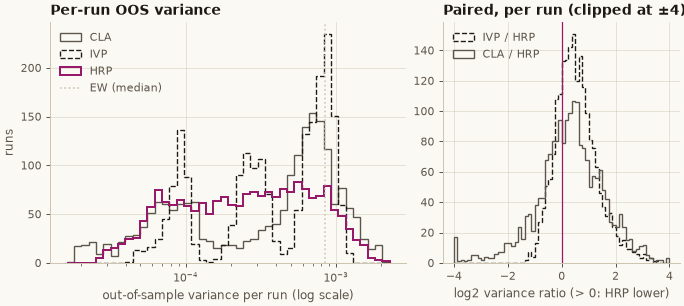

In [7]:
def draw(fig, c):
    left, right = fig.subplots(1, 2, width_ratios=[3, 2])
    styles = {
        "HRP": (c["accent"], "-", 1.6),
        "IVP": (c["text"], "--", 1.1),
        "CLA": (c["muted"], "-", 1.1),
        "EW": (c["rule"], ":", 1.3),
    }
    lo = math.log10(min(wide[m].min() for m in ORDER))
    hi = math.log10(max(wide[m].max() for m in ORDER))
    # Padded so the smallest and largest runs sit inside the outer edges, not on them: an
    # edge recomputed from the data can land a last bit either side of it, platform by platform.
    pad = 0.01 * (hi - lo)
    bins = np.logspace(lo - pad, hi + pad, 45)
    for m in ("CLA", "IVP", "HRP"):
        col, ls, lw = styles[m]
        left.hist(
            wide[m].to_numpy(),
            bins=bins,
            histtype="step",
            color=col,
            linestyle=ls,
            linewidth=lw,
            label=m,
        )
    # EW's variance barely varies across runs; a histogram of it would be one tall spike.
    col, ls, lw = styles["EW"]
    left.axvline(
        float(np.median(wide["EW"].to_numpy())),
        color=col,
        linestyle=ls,
        linewidth=lw,
        label="EW (median)",
    )
    left.set_xscale("log")
    left.set_xlabel("out-of-sample variance per run (log scale)")
    left.set_ylabel("runs")
    left.set_title("Per-run OOS variance")
    left.legend(loc="upper left")

    ratios = {m: np.log2(wide[m].to_numpy() / wide["HRP"].to_numpy()) for m in ("IVP", "CLA")}
    rb = np.linspace(-4.0, 4.0, 65)
    for m, arr in ratios.items():
        col, ls, lw = styles[m]
        right.hist(
            np.clip(arr, rb[0], rb[-1]),
            bins=rb,
            histtype="step",
            color=col,
            linestyle=ls,
            linewidth=lw,
            label=f"{m} / HRP",
        )
    right.axvline(0.0, color=c["accent"], linewidth=1.0)
    right.set_xlabel("log2 variance ratio (> 0: HRP lower)")
    right.set_title("Paired, per run (clipped at ±4)")
    right.legend(loc="upper left")


nbfigures.figure(
    "nb10-oos-variance",
    draw,
    size=(7.6, 3.4),
    alt="Left: distributions of per-run out-of-sample variance for HRP, IVP, CLA and equal weight in the synthetic Monte Carlo. Right: per-run log2 ratios of IVP and CLA variance to HRP variance.",
)

In [8]:
summary = (
    runs.group_by("method")
    .agg(
        pl.col("eff_n").mean().alias("effective N (of 10)"),
        pl.col("max_w").mean().alias("largest weight"),
        pl.col("turnover").mean().alias("turnover / rebalance"),
        (pl.col("var").mean() * 1e4).alias("OOS var x1e4, gross"),
        (pl.col("var_net").mean() * 1e4).alias(f"OOS var x1e4, net {COST_BPS:g} bps"),
    )
    .with_columns(
        pl.col("method")
        .replace_strict({m: i for i, m in enumerate(ORDER)}, return_dtype=pl.Int32)
        .alias("_o")
    )
    .sort("_o")
    .drop("_o")
)
with pl.Config(tbl_cols=-1, tbl_width_chars=200, float_precision=3, tbl_hide_dataframe_shape=True):
    print(summary)

┌────────┬─────────────────────┬────────────────┬──────────────────────┬─────────────────────┬──────────────────────────┐
│ method ┆ effective N (of 10) ┆ largest weight ┆ turnover / rebalance ┆ OOS var x1e4, gross ┆ OOS var x1e4, net 10 bps │
│ ---    ┆ ---                 ┆ ---            ┆ ---                  ┆ ---                 ┆ ---                      │
│ str    ┆ f64                 ┆ f64            ┆ f64                  ┆ f64                 ┆ f64                      │
╞════════╪═════════════════════╪════════════════╪══════════════════════╪═════════════════════╪══════════════════════════╡
│ HRP    ┆ 7.254               ┆ 0.199          ┆ 0.216                ┆ 3.903               ┆ 3.903                    │
│ IVP    ┆ 8.262               ┆ 0.139          ┆ 0.073                ┆ 5.013               ┆ 5.013                    │
│ CLA    ┆ 5.360               ┆ 0.238          ┆ 0.188                ┆ 5.162               ┆ 5.162                    │
│ EW     ┆ 10.000       

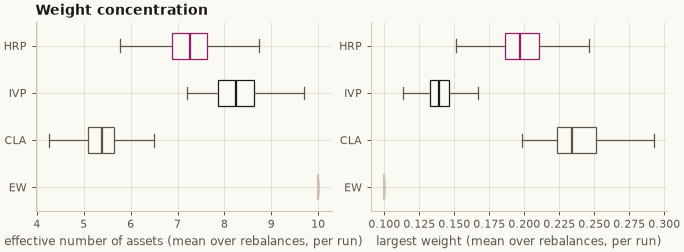

In [9]:
def draw(fig, c):
    left, right = fig.subplots(1, 2)
    colors = {"HRP": c["accent"], "IVP": c["text"], "CLA": c["muted"], "EW": c["rule"]}
    for ax, col, label in (
        (left, "eff_n", "effective number of assets"),
        (right, "max_w", "largest weight"),
    ):
        data = [runs.filter(pl.col("method") == m)[col].to_numpy() for m in ORDER]
        parts = ax.boxplot(
            data,
            orientation="horizontal",
            tick_labels=ORDER,
            showfliers=False,
            widths=0.55,
            patch_artist=True,
        )
        for patch, m in zip(parts["boxes"], ORDER):
            patch.set_facecolor(c["ground"])
            patch.set_edgecolor(colors[m])
        for key in ("whiskers", "caps"):
            for line in parts[key]:
                line.set_color(c["muted"])
        for line, m in zip(parts["medians"], ORDER):
            line.set_color(colors[m])
            line.set_linewidth(1.8)
        ax.invert_yaxis()
        ax.set_xlabel(label + " (mean over rebalances, per run)")
    left.set_title("Weight concentration")


nbfigures.figure(
    "nb10-weight-concentration",
    draw,
    size=(7.6, 2.8),
    alt="Box plots across Monte Carlo runs of the effective number of assets and the largest weight for HRP, IVP, CLA and equal weight.",
)

### Illustration: the same rolling procedure on `fetch()` data

One path, five assets, twelve rebalances: this shows the pipeline running on the data layer, not
evidence for or against the hypothesis. With `SOURCE = None` the data is the SYNTHETIC sample.

In [10]:
bars, meta = openquant.data.fetch(SYMBOLS, START, END, source=SOURCE, return_meta=True)
closes = (
    bars.pivot(on="symbol", index="ts", values="close")
    .select(["ts", *SYMBOLS])
    .drop_nulls()
    .sort("ts")
)
px = closes.select(SYMBOLS).to_numpy()
rets = px[1:] / px[:-1] - 1.0  # simple returns, rows are dates
dates = closes["ts"].to_list()[1:]
print("source:", meta["source"], "| SYNTHETIC" if SOURCE is None else "")
print("dataset_hash:", meta["dataset_hash"], "| return rows:", len(rets))

window, step = min(S_LENGTH, len(rets) // 2), REBAL
illus = {m: [] for m in ("HRP", "CLA", "IVP", "EW")}
turn = {m: [] for m in illus}
prev = {m: np.zeros(len(SYMBOLS)) for m in illus}
for t in range(window, len(rets), step):
    cov = np.cov(rets[t - window : t], rowvar=False)
    for m in illus:
        w = METHODS[m](cov)
        r = rets[t : t + step] @ w
        to = float(np.abs(w - prev[m]).sum())
        r[0] -= COST_BPS * 1e-4 * to
        illus[m].append(r)
        turn[m].append(to)
        prev[m] = w
oos_dates = dates[window:]
illus = {m: np.concatenate(v) for m, v in illus.items()}
ill = pl.DataFrame(
    [
        {
            "method": m,
            "ann. vol (net)": float(r.std(ddof=1) * math.sqrt(252)),
            "ann. Sharpe (net, rf=0)": float(r.mean() / r.std(ddof=1) * math.sqrt(252)),
            "turnover / rebalance": float(np.mean(turn[m][1:])),
        }
        for m, r in illus.items()
    ]
)
print(
    f"out-of-sample: {oos_dates[0].date()} -> {oos_dates[-1].date()}, {len(oos_dates)} days, one path"
)
with pl.Config(tbl_cols=-1, float_precision=4, tbl_hide_dataframe_shape=True):
    print(ill)

source: openquant-synthetic-sample | SYNTHETIC
dataset_hash: sha256:b311c219efb2a19db449767cc8600139c030aad15496b011fc650b4880550eea | return rows: 519
out-of-sample: 2023-01-02 -> 2023-12-29, 260 days, one path
┌────────┬────────────────┬─────────────────────────┬──────────────────────┐
│ method ┆ ann. vol (net) ┆ ann. Sharpe (net, rf=0) ┆ turnover / rebalance │
│ ---    ┆ ---            ┆ ---                     ┆ ---                  │
│ str    ┆ f64            ┆ f64                     ┆ f64                  │
╞════════╪════════════════╪═════════════════════════╪══════════════════════╡
│ HRP    ┆ 0.0979         ┆ 0.0036                  ┆ 0.0392               │
│ CLA    ┆ 0.0929         ┆ 0.6241                  ┆ 0.0435               │
│ IVP    ┆ 0.1026         ┆ 0.3053                  ┆ 0.0285               │
│ EW     ┆ 0.1158         ┆ -0.2970                 ┆ 0.0000               │
└────────┴────────────────┴─────────────────────────┴──────────────────────┘


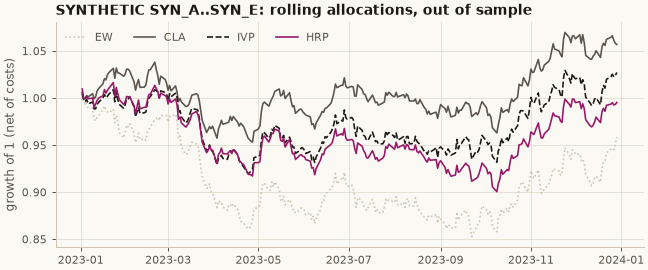

In [11]:
def draw(fig, c):
    ax = fig.subplots()
    styles = {
        "HRP": (c["accent"], "-"),
        "IVP": (c["text"], "--"),
        "CLA": (c["muted"], "-"),
        "EW": (c["rule"], ":"),
    }
    for m in ("EW", "CLA", "IVP", "HRP"):
        col, ls = styles[m]
        ax.plot(oos_dates, np.cumprod(1.0 + illus[m]), color=col, linestyle=ls, label=m)
    ax.set_ylabel("growth of 1 (net of costs)")
    ax.set_title(
        "SYNTHETIC SYN_A..SYN_E: rolling allocations, out of sample"
        if SOURCE is None
        else "Rolling allocations, out of sample"
    )
    ax.legend(loc="upper left", ncols=4)


nbfigures.figure(
    "nb10-fetch-illustration",
    draw,
    size=(7.2, 3.0),
    alt="Out-of-sample growth of one unit for HRP, IVP, CLA and equal weight on the synthetic five-symbol sample, 2023.",
)

## Analysis

All figures below are from the SYNTHETIC Monte Carlo with 2,000 runs (the committed outputs). A local
run with `OPENQUANT_RUNBOOK_RUNS=10000`, the book's count, gave the same picture: mean variance ratios
to HRP of 1.300 (IVP) and 1.337 (CLA), $t$ = 71.8 and 25.8.

**Both hypotheses hold under the Snippet 16.4 process.** HRP's mean OOS variance is about 24% below
CLA's minimum-variance portfolio (ratio 1.32) and 22% below IVP's (ratio 1.28), and it is lower in 62%
and 76% of individual runs. The paired log-ratio $t$-statistics (10.6 and 31.5) leave no doubt about the
sign; the effect sizes are what deserve reading. Equal weight, which estimates nothing, has more than
twice HRP's variance, because it always holds a full tenth of every shocked asset.

**How this compares with the book.** Quoting from memory, AFML §16.6 reports out-of-sample variances in
which CLA's is about 72% higher than HRP's and IVP's about 38% higher (ratios near 1.72 and 1.38); check
the section before citing these figures. Our ratios point the same way but are smaller: 1.32 and 1.28 on
mean per-run variance. The statistic matters, too. As I recall Snippet 16.5, it stores each run's OOS
*standard deviation* and reports the variance of those across runs, which measures the spread of
outcomes rather than their level. Computed that way here, CLA is 1.36× HRP, close to the book's
ordering, but IVP comes out *below* HRP (0.90×): IVP's outcomes are less dispersed across runs even
though they are worse on average. Candidate reasons for the gap in magnitude, none tested here:

- **Tree construction.** Snippet 16.1 passes the square distance matrix to scipy, which treats its rows
  as coordinates, so the book clusters on distances *between rows of the distance matrix*;
  `openquant.hrp` clusters on the pairwise correlation distances directly (see the `hrp` page).
- **CLA inputs.** Both use the dummy means and the last (minimum-variance) turning point; a numerically
  different turning-point path could still leave a different last point when the covariance is nearly
  singular, which it is here (five near-duplicate pairs).
- **Sampling.** Different generators and seeds; with 2,000 or 10,000 runs this is too small to explain it.

**Concentration and turnover.** HRP's effective number of assets (7.3 of 10) lies between CLA's (5.4)
and IVP's (8.3). That is the intended behaviour: IVP spreads weight evenly across near-duplicates, so a
duplicated asset gets twice the weight, while HRP recognises each pair as one bet. CLA concentrates
most, and its largest weight averages 0.24. HRP is not the most *stable*, though: its turnover per
rebalance (0.22) is higher than CLA's (0.19) and three times IVP's (0.07). Single linkage on
near-duplicate pairs can reorder the leaves from one window to the next, and bisecting the leaf *list*
then moves weight between halves. At the stated 10 bps cost it leaves every variance unchanged to four
significant digits, so it does not affect H1 or H2, but it matters for an allocator that trades.

**The `fetch()` illustration** is one five-asset path and supports no inference; on it CLA had the
lowest volatility. It is there to show the procedure running on the data layer.

**Limits.** The generative process is the book's and is favourable to hierarchical methods by design:
clusters are clean pairs and the shocks hit a cluster or a single asset out of sample. The result says
HRP is robust *to this kind of structure and shock*; it does not say HRP lowers variance on any real
universe.

## Promotion decision

**Replicated on synthetic data; not promoted as a market claim.**

- H1 (HRP below CLA minimum variance) and H2 (HRP not worse than IVP) are **supported** under AFML's
  Snippet 16.4 process, in direction; the effect is smaller than the book reports.
- What this promotes: the `hrp` and `cla` bindings reproduce the chapter's qualitative result, and the
  runbook is a working template for the same study on real data.
- What it does not: any statement that HRP lowers variance on real assets. That needs the rolling study
  on a real multi-asset universe (issue #51's original scope), run with `SOURCE` set to the user's own
  data, net of costs, with its trial count recorded, and it stays open.
- Follow-ups worth filing: HRP's turnover being above CLA's on near-duplicate assets; HCAA returning
  HRP's weights (#108).

## Self-review checklist

- [x] **No lookahead.** Weights at rebalance $t$ use rows $[t-260, t)$ only; the test cell replaces every
  row from $t$ on with noise and asserts bit-identical weights at all 12 dates, and checks that editing
  row $t-1$ does move them. Held returns start at row $t$. The illustration uses the same indexing, with
  returns built from closes $t-1 \to t$.
- [x] **Shocks are out of sample by construction** (Snippet 16.4 draws their dates from $[260, 519)$).
- [x] **Same inputs for every method:** one covariance matrix per rebalance, passed to all four.
- [x] **Seeds fixed:** run $k$ uses `default_rng([51, k])`; the no-lookahead tamper uses `[51, 10**9]`, outside the run range.
- [x] **Costs stated:** 10 bps per unit of one-way turnover; the gross and net variances are both shown.
- [x] **Trial count complete** (next cell). `openquant.evaluation`'s trial registry is not on this
  base (it is in unmerged PR #139), so the trials are listed by hand. No Sharpe-based selection is made,
  so no deflated Sharpe ratio is computed; the count is recorded for when one is.
- [x] **Labelled SYNTHETIC** everywhere a number appears.

In [12]:
# Every configuration evaluated while writing this runbook, including exploratory runs.
TRIALS = [
    {"trial": 1, "what": "prototype, 200 runs, HRP/IVP/CLA, book parameters", "kept": False},
    {
        "trial": 2,
        "what": "prototype, 200 runs, + HCAA(minimum_variance) and EW; HCAA == HRP (#108), dropped",
        "kept": False,
    },
    {
        "trial": 3,
        "what": f"this notebook, {N_RUNS_CI} runs (CI), HRP/CLA/IVP/EW, book parameters",
        "kept": True,
    },
]
print(
    "configurations evaluated:",
    len(TRIALS),
    "| generative/method parameters changed between trials: none",
)
for t in TRIALS:
    print(f"  {t['trial']}. {t['what']}{'  <- reported' if t['kept'] else ''}")

configurations evaluated: 3 | generative/method parameters changed between trials: none
  1. prototype, 200 runs, HRP/IVP/CLA, book parameters
  2. prototype, 200 runs, + HCAA(minimum_variance) and EW; HCAA == HRP (#108), dropped
  3. this notebook, 2000 runs (CI), HRP/CLA/IVP/EW, book parameters  <- reported


## Reproducibility

In [13]:
import subprocess
import sys

print(
    "openquant (pyopenquant)",
    version("pyopenquant"),
    "| numpy",
    np.__version__,
    "| polars",
    pl.__version__,
)
print("seed:", SEED, "| runs:", N_RUNS, "| cost:", COST_BPS, "bps")
print("Monte Carlo data hash:", MC_DATA_HASH)
print("fetch dataset_hash:", meta["dataset_hash"], "| source:", meta["source"])
# The commit necessarily changes with every commit, so it goes to stderr, which the committed-output
# check (`just notebooks-verify`) ignores; it is still saved in the executed notebook.
try:
    sha = subprocess.run(
        ["git", "rev-parse", "HEAD"], capture_output=True, text=True, check=True
    ).stdout.strip()
    dirty = (
        subprocess.run(
            ["git", "status", "--porcelain"], capture_output=True, text=True
        ).stdout.strip()
        != ""
    )
    print(f"git: {sha}{' (dirty working tree)' if dirty else ''}", file=sys.stderr)
except (OSError, subprocess.CalledProcessError):
    print("git: unavailable", file=sys.stderr)

openquant (pyopenquant) 0.1.0 | numpy 2.4.6 | polars 1.44.2
seed: 51 | runs: 2000 | cost: 10.0 bps
Monte Carlo data hash: sha256:4d7244f3bfde30f5e2cf082468941a4a64c6f0200dfd8bcc3ffe07f5f29879cc
fetch dataset_hash: sha256:b311c219efb2a19db449767cc8600139c030aad15496b011fc650b4880550eea | source: openquant-synthetic-sample


git: 50d55168f969995ffe3da665d03c99a69d9895e0 (dirty working tree)
